# Homework 6: Satellite Remote Sensing & Vegetation Phenology
## F&W ECOL 458: Environmental Data Science

**Covers:** Lectures 12-13 (Remote Sensing with GEE, Land Cover & Phenology)

### [**Ines Lopez-Silvero**]

**Total Points:** 100

---

### Instructions

1. Complete all problems in this notebook
2. Write your code in the provided cells
3. Answer written questions in markdown cells
4. Run all cells before submitting to ensure they execute without errors
5. Submit the completed `.ipynb` file

### Study Area

For this assignment, you will analyze **your home county** (or a county of your choice in the continental US). This allows you to connect remote sensing concepts to a familiar landscape.

---

In [3]:
# Setup - Run this cell first
!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.9 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='fw-ecol-lopez-silvero')  # Replace with your project ID

---
## Problem 1: Define Your Study Area (5 points)

Define a study area for your analysis. You can either:
- Use a bounding box (rectangle) around your home county, OR
- Load county boundaries from the US Census TIGER dataset

**Tasks:**
1. Create a geometry for your study area
2. Create an interactive map showing your study area
3. State which county/region you selected

In [11]:
# Option A: Define a bounding box [west, south, east, north]
# Example for Dane County, WI:
# study_area = ee.Geometry.Rectangle([-89.8, 42.85, -89.0, 43.35])

# Option B: Load from US Census TIGER counties
# counties = ee.FeatureCollection('TIGER/2018/Counties')
# study_area = counties.filter(ee.Filter.eq('NAME', 'YourCountyName')).geometry()

# YOUR CODE HERE
study_area = ee.Geometry.Rectangle([-74.45,40.65,-74.25,40.80])  # Replace with your geometry


In [12]:
# Create a map showing your study area
# YOUR CODE HERE
Map=geemap.Map(center=[40.65,-74.45],zoom=14)
Map.addLayer(study_area, {'color': 'blue'}, 'Summit(Rectangle)')
Map.centerObject(study_area,12)
Map

Map(center=[40.72501497547275, -74.34999999999984], controls=(WidgetControl(options=['position', 'transparent_…

**Your answer:** I selected Summit,New Jersey because I was born and raised there. It is my hometown and I think its such a perfect little town where you can walk everywhere and enjoy all the little stores with your friends and family.The rectangle also highlights neirboring towns because a lot of my friends from schoo lived in those areas so I would always travel to those places.

---
## Problem 2: Conceptual Questions (15 points)

Answer the following questions about remote sensing concepts. Write your answers in the markdown cells provided.

### 2.1 Spectral Signatures (5 points)

Explain why healthy vegetation appears **dark in the red band** but **bright in the near-infrared (NIR) band**. What biological/physical properties of leaves cause this pattern?

**Your answer:** Plants absorbs red light primarily because of chlorophyll. It captures these wavelenghts and converts it into energy. So because they absorb all this red light, vegetation looks dark in the red band because it isn't reflecting any of that light. However, vegetation appears bright in NIR bands because this band is outside the ideal absroption rate for plants. NIR light is too intense for plants that if plants were to absorb any of this light they would likely die.So insetad of absorpotion, they reflect the light back ,through their spongy layer in their leaf structure. This layer is filled with water which basically reflects back the NIR light to remain cool, thus resulting in a bright band.



### 2.2 NDVI Interpretation (5 points)

You calculate NDVI for three pixels and get the following values:
- Pixel A: NDVI = 0.85
- Pixel B: NDVI = 0.15
- Pixel C: NDVI = -0.25

What type of land cover does each pixel most likely represent? Explain your reasoning.

**Your answer:** Pixel A has a NDVI (Normalized Difference Vegetation Index) of 0.85 so the region has healthy vegetation. This is because healthy plants with high chlorophyll reflect more NIR light resulting in a higher NDVI level. Pixel B has a NDVI of 0.15 so the region has bare soil. This is because the region is likely to be distressed, absorbing more NIR light, thus lowering the index. Laslty pixel C has a NDVI of -0.25 which means the region is just water. So there is no absorbtion what so ever of NIR because its just water.



### 2.3 Spatial vs Temporal Resolution (5 points)

Landsat has 30m spatial resolution with 16-day revisit, while MODIS has 250-500m resolution with daily coverage.

For each scenario below, which sensor would you choose and why?

a) Mapping urban expansion in a city over 20 years

b) Tracking the progression of fall leaf color change across a state

**Your answer:** For part a I would choose a temporal resolution because you would be tracking urban expansion over 20 years. We are looking at the when and how fast this expansion can be completed. For part b I would choose spatial resolution because you are focusing on specifc details like leaf color change. Spatial resolution is used to identify fine details in certain locations.



---
## Problem 3: Create a Summer Composite (20 points)

Create a cloud-free Landsat 8 composite for summer 2023 (June-August) for your study area.

**Tasks:**
1. Load and filter the Landsat 8 Collection 2 Surface Reflectance data (5 pts)
2. Apply scaling factors and cloud masking (5 pts)
3. Create a median composite (5 pts)
4. Display the composite in both true color and false color (5 pts)

In [18]:
# 3.1 Load Landsat 8 and filter by date, location, and cloud cover
# YOUR CODE HERE

landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

filtered = (landsat
            .filterDate('2023-06-01', '2023-08-31')
            .filterBounds(study_area)
            .filter(ee.Filter.lt('CLOUD_COVER',20)) # Relaxed cloud cover filter

)  # Replace with your filtered collection





print(f"Number of images: {filtered.size().getInfo()}")

Number of images: 2


In [15]:
# 3.2 Define scaling and cloud masking functions
# YOUR CODE HERE

def scale_landsat(image):
    optical_bands=['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    optical=image.select(optical_bands)
    scaled=optical.multiply(0.0000275).add(-0.2)
    return image.addBands(scaled, overwrite=True)
scaled_collection=filtered.map(scale_landsat)

def mask_clouds(image):
   qa=image.select('QA_PIXEL')
   cloud_mask=qa.bitwiseAnd(1<<3).eq(0)
   return image.updateMask(cloud_mask)




In [16]:
# 3.3 Apply functions and create median composite
# YOUR CODE HERE

composite=scaled_collection.median().clip(study_area)

In [19]:
# 3.4 Display in true color AND false color (NIR, Red, Green)
# YOUR CODE HERE
true_color={
    'bands':['SR_B4','SR_B3','SR_B2'],
    'min':0.0,
    'max':0.3
}

false_color={
    'bands':['SR_B5','SR_B4','SR_B3'], # Corrected 'SR_B' to 'SR_B3'
    'min':0.0,
    'max':0.4
}

Map=geemap.Map(center=[40.65,-74.45],zoom=10)
Map.addLayer(composite,true_color,'True Color')
Map.addLayer(composite,false_color,'False Color')
Map.centerObject(study_area,12)
Map

Map(center=[40.72501497547085, -74.34999999999984], controls=(WidgetControl(options=['position', 'transparent_…

---
## Problem 4: Spectral Indices Analysis (20 points)

Calculate and analyze spectral indices for your study area.

**Tasks:**
1. Calculate NDVI, NDWI, and NDBI for your composite (6 pts)
2. Create a map showing all three indices with appropriate color palettes (6 pts)
3. Identify and describe three distinct landscape features visible in your indices (8 pts)

In [31]:
# 4.1 Calculate spectral indices
# NDVI = (NIR - Red) / (NIR + Red)
# NDWI = (Green - NIR) / (Green + NIR)
# NDBI = (SWIR1 - NIR) / (SWIR1 + NIR)

# YOUR CODE HERE

ndvi = composite.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')
ndbi = composite.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')


In [29]:
# 4.2 Create maps for each index with appropriate visualization
# YOUR CODE HERE

Map=geemap.Map(center=[40.65,-74.45],zoom=10)

Map.addLayer(ndvi.clip(study_area),
             {'min':0.2,'max':0.8,'palette':['brown','yellow','green']},
             'NDVI (Vegetation)')
Map.addLayer(ndwi.clip(study_area),
             {'min':-0.1, 'max':0.3, 'palette':[ 'white','blue']},
             'NDWI (Water)')
Map.addLayer(ndbi.clip(study_area),
             {'min':-0.2, 'max':0.3, 'palette':['grey', 'white','red']},
             'NDBI(Built-up)')

Map





Map(center=[40.65, -74.45], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

### 4.3 Landscape Feature Identification (8 points)

Identify **three distinct landscape features** in your study area that are clearly visible in your spectral indices. For each feature:
- Describe what it is (lake, forest, urban area, farm field, etc.)
- State which index shows it most clearly
- Explain why that index highlights this feature

**Feature 1:** The light grey/white represents the Normalized Difference Build-Up Index. Those areas represent dense urban environments where there are a lot of roads, buildings, and industrial zones. These man-made materials reflect short wave infared light which is highlighted through NDBI.

**Feature 2:** The dark grey areas represent the forested areas. This study area is mostly trees but a mix of buildings, it absorbs the short wave infared light. In those dark areas there is hardly any reflections so the index is low.

**Feature 3:**The red spots represent the Normalized Difference Built-up Index. The areas where the red is reflected are areas near major highways and construction areas. Materials like concrete and asphalt can't absorb red light. Instead it reflects it back, showing up as red dots on the map.


---
## Problem 5: Land Cover Analysis (20 points)

Analyze the land cover composition of your study area using NLCD.

**Tasks:**
1. Load NLCD 2021 and clip to your study area (4 pts)
2. Calculate the area (in km²) of each land cover class (8 pts)
3. Create a bar chart showing land cover distribution (4 pts)
4. Answer the interpretation questions (4 pts)

In [33]:
# 5.1 Load NLCD 2021
# YOUR CODE HERE

nlcd = ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD')

nlcd_2021=nlcd.filter(ee.Filter.eq('system:index','2021')).first().select('landcover').clip(study_area)



In [35]:
# 5.2 Calculate area per land cover class
# Hint: Use ee.Image.pixelArea() and reduceRegion with ee.Reducer.sum().group()

# Class name lookup dictionary
class_names = {
    11: 'Open Water',
    21: 'Developed, Open',
    22: 'Developed, Low',
    23: 'Developed, Medium',
    24: 'Developed, High',
    31: 'Barren',
    41: 'Deciduous Forest',
    42: 'Evergreen Forest',
    43: 'Mixed Forest',
    52: 'Shrub/Scrub',
    71: 'Grassland',
    81: 'Pasture/Hay',
    82: 'Cultivated Crops',
    90: 'Woody Wetlands',
    95: 'Herbaceous Wetlands'
}

# YOUR CODE HERE

area_per_class=ee.Image.pixelArea().addBands(nlcd_2021) # Corrected 'Imgae' to 'Image' and added nlcd_2021 instead of nlcd
stats=area_per_class.reduceRegion(
    reducer=ee.Reducer.sum().group(
        groupField=1,
        groupName='class'
    ),
    geometry=study_area,
    scale=30,
    maxPixels=1e9 # Added maxPixels to prevent potential EEException
)

area_stats=stats.get('groups').getInfo()
final_results=[]

print(f"{'Class Name':<20}| {'Area (km²)':>10}")
print('-'*40)

for item in area_stats:
    class_id=item['class']
    class_name=class_names.get(class_id, 'Unknown')
    area_km2=item['sum']/1e6
    print(f"{class_name:<20}| {area_km2:>10.2f}")

Class Name          | Area (km²)
----------------------------------------
Open Water          |       2.38
Developed, Open     |      89.17
Developed, Low      |      64.06
Developed, Medium   |      37.56
Developed, High     |      13.99
Barren              |       0.67
Deciduous Forest    |      35.41
Evergreen Forest    |       0.06
Mixed Forest        |       3.56
Shrub/Scrub         |       0.22
Grassland           |       0.47
Pasture/Hay         |       2.06
Cultivated Crops    |       0.05
Woody Wetlands      |      31.08
Herbaceous Wetlands |       0.72


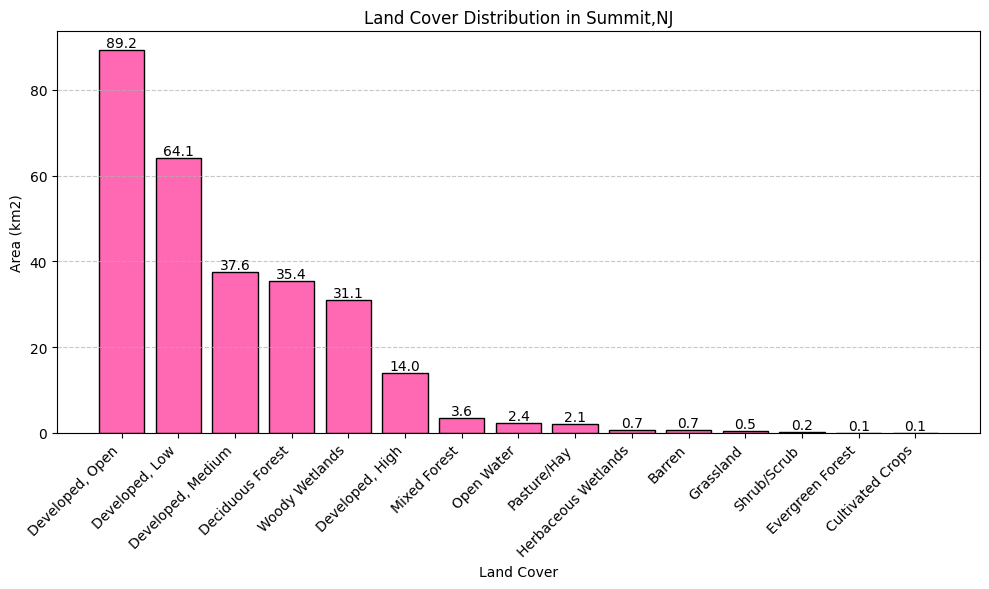

In [37]:
# 5.3 Create a bar chart of land cover distribution
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt

data_df=[]
for item in area_stats:
    class_id= item['class']
    class_name=class_names.get(class_id, f'Unknown ({class_id})')
    area_km2=item['sum']/1e6
    data_df.append({'Land Cover':class_name, 'Area (km2)':area_km2})

#


df=pd.DataFrame(data_df).sort_values(by='Area (km2)', ascending=False)
plt.figure(figsize=(10,6))
bars=plt.bar(df['Land Cover'],df['Area (km2)'], color='hotpink',edgecolor='black')



plt.xlabel('Land Cover')
plt.ylabel('Area (km2)')
plt.title('Land Cover Distribution in Summit,NJ')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
for bar in bars:
  yval=bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2,yval,round(yval,1),ha='center',va='bottom')

plt.tight_layout()
plt.show()

### 5.4 Interpretation Questions (4 points)

a) What are the **two most dominant** land cover types in your study area? Does this match your expectations based on your knowledge of the region?

**Your answer:** The two most dominant land covers are "Developed, Open" and "Developed,Low". This is expected becasue this area has a mix of construction materials and vegetation, mostly in the form of lawns.


b) What percentage of your study area is **developed** (sum of all developed classes)? How does this compare to the percentage of **forest** (sum of all forest classes)?

**Your answer:** The sum of all the areas is 281.8 km^2 and the sum of all developed areas is 204.9 km^2. The percentage of developed is about 72.7% (204.9/281.8). The sum of forest areas is 39.1km^2. So the percentage of forest is 13.9% (39.1/281.8). 73% is a lot greater than 13.9%. Forest cover is signficantly lower than developed land cover.



---
## Problem 6: Phenology Analysis (20 points)

Analyze vegetation phenology at a specific location in your study area.

**Tasks:**
1. Select a vegetated point in your study area (forest or agriculture) (2 pts)
2. Extract MODIS NDVI time series for 2023 (6 pts)
3. Plot the NDVI time series (4 pts)
4. Calculate and report phenological metrics (8 pts)

In [51]:
# 6.1 Define a point location in a vegetated area
# Choose a forest, agricultural field, or other vegetated location

# YOUR CODE HERE
veg_point = ee.Geometry.Point([-74.37, 40.69])
 # ee.Geometry.Point([longitude, latitude])

print(f"Selected location: [Watching Reservation in New Jersey: A large forest]")

Selected location: [Watching Reservation in New Jersey: A large forest]


In [55]:
# 6.2 Load MODIS NDVI and extract time series at your point
# Use: MODIS/061/MOD13Q1 (16-day NDVI)
# Remember to scale NDVI by 0.0001

# YOUR CODE HERE

modis = ee.ImageCollection('MODIS/061/MOD13Q1')

# Filter, scale, and extract values
modis_filtered= (modis
        .filterDate('2023-01-01', '2023-12-31') # Corrected filterData to filterDate and adjusted date range to cover the whole year for phenology
        .filterBounds(veg_point)
        .select('NDVI')
        )
print(f"MODIS images in 2023: {modis_filtered.size().getInfo()}")
print("16-day composites= ~23 images per year")

def scale_modis(image):
    return image.multiply(0.0001).copyProperties(image, ['system:time_start'])

scaled_modis=modis_filtered.map(scale_modis)

MODIS images in 2023: 23
16-day composites= ~23 images per year


In [52]:
# Convert to pandas DataFrame
# YOUR CODE HERE
data=scaled_modis.getRegion(veg_point,250).getInfo()
import pandas as pd
df=pd.DataFrame(data[1:],columns=data[0]) # Your DataFrame with 'date', 'doy', and 'NDVI' columns
df['date']=pd.to_datetime(df['time'],unit='ms') # Changed 'data' to 'date'
df['doy']=df['date'].dt.dayofyear
df['NDVI']=pd.to_numeric(df['NDVI'], errors='coerce')
df.head()

,id,longitude,latitude,time,NDVI,date,doy
0,2023_01_01,-74.370399,40.690314,1672531200000,0.4512,2023-01-01,1
1,2023_01_17,-74.370399,40.690314,1673913600000,0.4020,2023-01-17,17
2,2023_02_02,-74.370399,40.690314,1675296000000,0.4012,2023-02-02,33
3,2023_02_18,-74.370399,40.690314,1676678400000,0.4108,2023-02-18,49
4,2023_03_06,-74.370399,40.690314,1678060800000,0.3875,2023-03-06,65


Rows found: 23
        date    NDVI
0 2023-01-01  0.4512
1 2023-01-17  0.4020
2 2023-02-02  0.4012
3 2023-02-18  0.4108
4 2023-03-06  0.3875


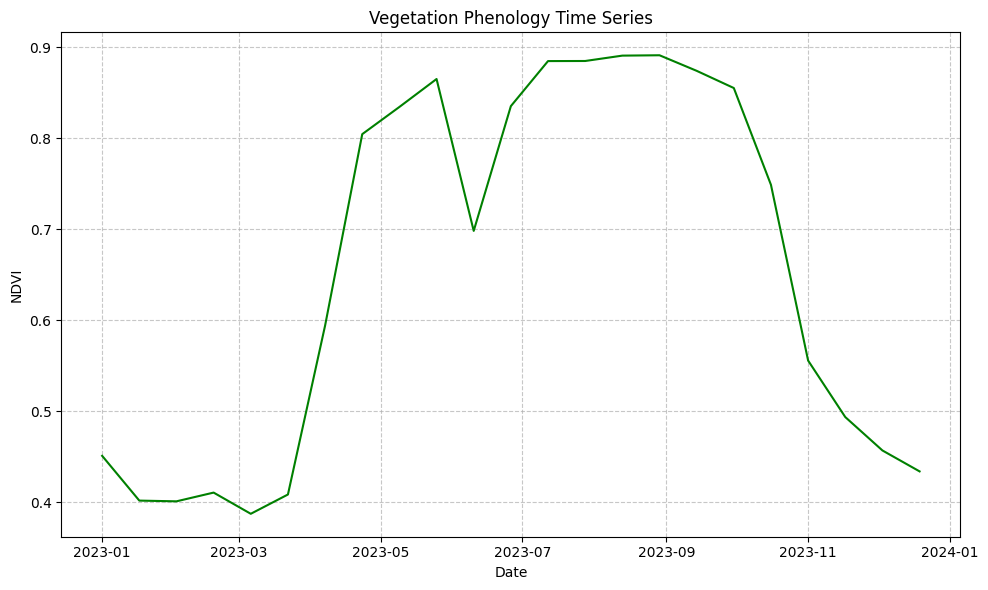

In [57]:
# 6.3 Plot the NDVI time series
# Include: axis labels, title, grid

# YOUR CODE HERE
df=df.dropna(subset=['NDVI']).sort_values('date')
print(f"Rows found: {len(df)}")
print(df[['date','NDVI']].head())

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(df['date'],df['NDVI'],linestyle='-',color='green')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Vegetation Phenology Time Series')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
# 6.4 Calculate phenological metrics
# Calculate and print:
# - Peak NDVI value and date
# - Minimum NDVI value
# - Amplitude (Peak - Min)
# - Start of Season (SOS): first date NDVI crosses 50% of amplitude (spring)
# - End of Season (EOS): first date NDVI drops below 50% of amplitude (fall)
# - Growing Season Length (EOS - SOS)

# YOUR CODE HERE

# Ensure NDVI is numeric and sort by date
df = df.dropna(subset=['NDVI']).sort_values('date').reset_index(drop=True)

# Check if DataFrame is empty after dropping NaNs
if df.empty:
    print("No valid NDVI data found for phenology analysis.")
else:
    # 1. Peak NDVI value and date
    peak_ndvi = df['NDVI'].max()
    peak_date = df.loc[df['NDVI'].idxmax()]['date']

    # 2. Minimum NDVI value
    min_ndvi = df['NDVI'].min()

    # 3. Amplitude (Peak - Min)
    amplitude = peak_ndvi - min_ndvi

    # Calculate 50% of amplitude threshold
    threshold_value = min_ndvi + (0.5 * amplitude)

    # 4. Start of Season (SOS)
    # Find the first date where NDVI crosses the threshold (rising limb)
    sos_candidates_df = df[df['NDVI'] >= threshold_value]
    sos_date = sos_candidates_df['date'].min() if not sos_candidates_df.empty else None

    # 5. End of Season (EOS)
    # Find the first date *after* the peak where NDVI drops below the threshold (falling limb)
    eos_date = None
    if sos_date is not None:
        # Get the index of the peak date to search for EOS after it
        peak_date_index = df[df['date'] == peak_date].index[0]
        # Look for EOS only in data points *after* the peak
        post_peak_df = df.iloc[peak_date_index:]
        eos_candidates_df = post_peak_df[post_peak_df['NDVI'] < threshold_value]
        # Take the first date *after the peak* that drops below the threshold
        eos_date = eos_candidates_df['date'].min() if not eos_candidates_df.empty else None

    # 6. Growing Season Length
    growing_season_length = None
    if sos_date and eos_date:
        growing_season_length = (eos_date - sos_date).days

    print(f"Peak NDVI value: {peak_ndvi:.3f} (on {peak_date.strftime('%Y-%m-%d')})")
    print(f"Minimum NDVI value: {min_ndvi:.3f}")
    print(f"Amplitude (Peak - Min): {amplitude:.3f}")
    print(f"Start of Season (SOS): {sos_date.strftime('%Y-%m-%d') if sos_date else 'N/A'} (DOY: {sos_date.dayofyear if sos_date else 'N/A'})")
    print(f"End of Season (EOS): {eos_date.strftime('%Y-%m-%d') if eos_date else 'N/A'} (DOY: {eos_date.dayofyear if eos_date else 'N/A'})")
    print(f"Growing Season Length: {growing_season_length if growing_season_length is not None else 'N/A'} days")

Peak NDVI value: 0.891 (on 2023-08-29)
Minimum NDVI value: 0.388
Amplitude (Peak - Min): 0.504
Start of Season (SOS): 2023-04-23 (DOY: 113)
End of Season (EOS): 2023-11-01 (DOY: 305)
Growing Season Length: 192 days


### 6.5 Phenology Interpretation (4 points)

Based on your phenology analysis:

a) When did peak greenness occur at your location? Is this timing consistent with what you would expect for this vegetation type and location?

**Your answer:** Peak greeness occured on August 29,2023.Yes this timing is consitent to what I would expect the vegetation to be thriving.


b) How long was the growing season? How might this compare to locations further north or south?

**Your answer:** The growing season was 192 days long. Well locations further north expericne short growing seasons because their seasons drastically change. Locations near the equator have little seasonal variation. This result in a more consistent long growing period.



---
## Submission Checklist

Before submitting, verify that you have:

- [ ] Defined your study area (Problem 1)
- [ ] Answered all conceptual questions (Problem 2)
- [ ] Created a summer composite with true and false color display (Problem 3)
- [ ] Calculated and mapped spectral indices (Problem 4)
- [ ] Analyzed land cover with area calculations and bar chart (Problem 5)
- [ ] Completed phenology analysis with time series and metrics (Problem 6)
- [ ] Run all cells to ensure they execute without errors
- [ ] Written clear interpretations for all written questions